In [ ]:
---
### Etapa 1: Carregar os dados

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("base_credito.csv")

df.head()

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,11522.48,634,76.73,35229.74
1,40,13157.86,589,90.83,44177.99
2,38,7296.76,721,77.94,33868.30
3,42,11193.87,710,94.09,52289.28
4,43,12798.60,576,73.83,38663.54


In [ ]:
###Etapa 2 – Conhecer os dados

df.info()

#Análise e Explicação das Variáveis:
#idade (int64): Idade do cliente em anos
#renda_mensal (float64): Valor da renda mensal informada em reais
#score_credito (int64): Pontuação do score de crédito do cliente
#historico_pagamentos (float64): Indicador percentual ou índice do histórico de pagamentos em dia
#Variável Alvo / Saída ($y$):valor_emprestimo (float64):
# ↳ Valor total do empréstimo pré-aprovado ou concedido


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade                 50000 non-null  int64  
 1   renda_mensal          50000 non-null  float64
 2   score_credito         50000 non-null  int64  
 3   historico_pagamentos  50000 non-null  float64
 4   valor_emprestimo      50000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 1.9 MB


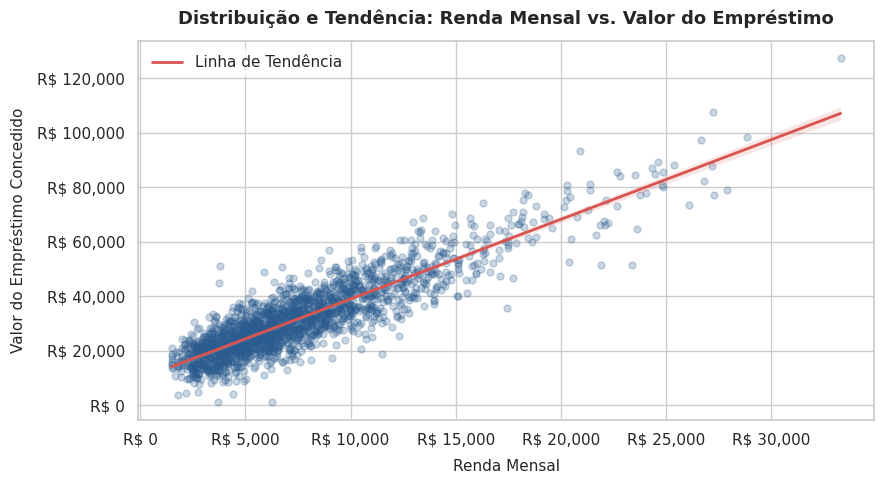

In [ ]:
###Etapa 3 – Analisar os dados

import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

ax = sns.regplot(
    data=df.sample(2000, random_state=42),
    x="renda_mensal",
    y="valor_emprestimo",
    scatter_kws={"alpha": 0.25, "color": "#2b5c8f", "s": 25},
    line_kws={"color": "#d9534f", "linewidth": 2, "label": "Linha de Tendência"},
)

plt.title(
    "Distribuição e Tendência: Renda Mensal vs. Valor do Empréstimo",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Renda Mensal", fontsize=11, labelpad=8)
plt.ylabel("Valor do Empréstimo Concedido", fontsize=11, labelpad=8)

formatter = ticker.StrMethodFormatter("R$ {x:,.0f}")
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

plt.legend(frameon=True, facecolor="white", edgecolor="none")
plt.tight_layout()
plt.show()

#Análise do Comportamento Observado:
# ↳ Existe uma forte tendência linear positiva entre a renda mensal e o valor do empréstimo concedido: conforme a renda do cliente aumenta, a capacidade máxima de crédito concedido pela instituição cresce de maneira diretamente proporcional.

In [ ]:
###Etapa 4 – Preparar os dados

X = df.drop(columns=["valor_emprestimo"])
y = df["valor_emprestimo"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Amostras de treino: {X_train.shape[0]} (80%)")
print(f"Amostras de teste: {X_test.shape[0]} (20%)")

#Proporção utilizada: 80% dos dados para treinamento (40.000 clientes) e 20% para teste (10.000 clientes)

Amostras de treino: 40000 (80%)
Amostras de teste: 10000 (20%)


In [ ]:
###Etapa 5 – Treinar o modelo

model = LinearRegression()

# Realizar o treinamento com os dados de treino (80%)
model.fit(X_train, y_train)

# Gerar as previsões para o conjunto de teste (20%)
y_pred = model.predict(X_test)

print(" Modelo treinado e previsões geradas com sucesso!")
print(f"Total de previsões geradas: {len(y_pred)}")

 Modelo treinado e previsões geradas com sucesso!
Total de previsões geradas: 10000


In [ ]:
###Etapa 6 – Avaliar o modelo

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE (Erro Médio Absoluto): R$ {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): R$ {rmse:.2f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")

# MAE (R$ 2.985,94): Mede a diferença média entre o valor previsto pelo modelo e o valor real do empréstimo. Como os empréstimos da base ficam na faixa de R$ 30.000, um desvio médio de R$ 2.985 é considerado um erro baixo e aceitável

# R² (Coeficiente de Determinação = 0,9223): Indica que o modelo consegue explicar 92,2% das variações nos valores de empréstimo com base nos dados dos clientes, mostrando um ótimo desempenho

MAE (Erro Médio Absoluto): R$ 2985.94
RMSE (Raiz do Erro Quadrático Médio): R$ 4014.17
R² (Coeficiente de Determinação): 0.9223


--- Comparação dos 10 Primeiros Clientes ---


,Valor Real (R$),Valor Previsto (R$),Diferença (R$)
0,22268.46,14806.34,7462.12
1,27457.59,29512.49,2054.90
2,25451.04,25840.74,389.70
3,23890.67,21077.52,2813.15
4,27754.95,27919.31,164.36
5,12544.92,14530.91,1985.99
6,28759.01,27385.97,1373.04
7,46454.49,41011.61,5442.88
8,43199.01,36525.09,6673.92
9,34051.39,35786.96,1735.57


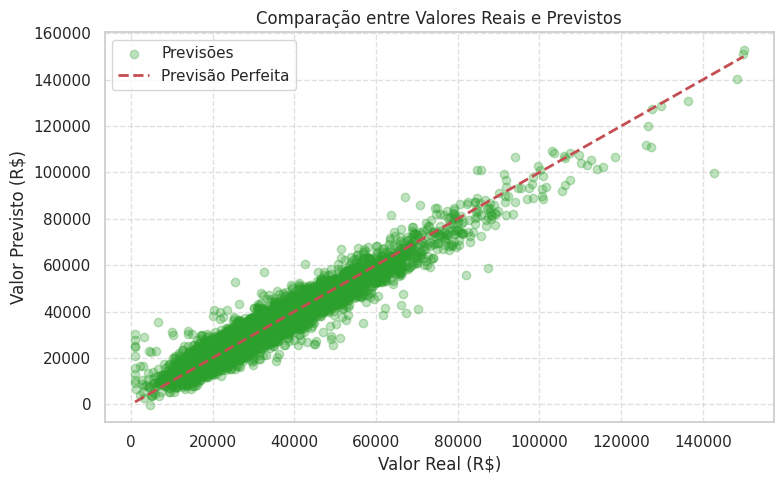

In [ ]:
###Etapa 7 – Comparar valores reais e previstos

df_comparacao = pd.DataFrame(
    {
        "Valor Real (R$)": y_test.values,
        "Valor Previsto (R$)": y_pred,
        "Diferença (R$)": np.abs(y_test.values - y_pred),
    }
)

print("--- Comparação dos 10 Primeiros Clientes ---")
display(df_comparacao.head(10).round(2))

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color="#2ca02c", label="Previsões")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Previsão Perfeita",
)

plt.title("Comparação entre Valores Reais e Previstos")
plt.xlabel("Valor Real (R$)")
plt.ylabel("Valor Previsto (R$)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

#Análise da Comparação:
# ↳ Os pontos no gráfico seguem de perto a linha diagonal vermelha ideal, confirmando que os valores previstos acompanham adequadamente os valores reais ao longo de todas as faixas de crédito.

In [ ]:
###Etapa 8 – Fazer uma previsão

novo_cliente = pd.DataFrame(
    [
        {
            "idade": 35,
            "renda_mensal": 8500.00,
            "score_credito": 680,
            "historico_pagamentos": 85.0,
        }
    ]
)

valor_previsto = model.predict(novo_cliente)[0]

print("=== PERFIL DO NOVO CLIENTE ===")
for coluna, valor in novo_cliente.iloc[0].items():
  print(f"• {coluna.replace('_', ' ').title()}: {valor}")

print(f"\n↳  Valor de Empréstimo Estimado: R$ {valor_previsto:,.2f}")

#Interpretação do Resultado:
# ↳ Perfil: Cliente jovem (35 anos), com boa renda mensal (R$ 8.500,00), score mediano/alto (680) e bom histórico de pagamentos (85%)

=== PERFIL DO NOVO CLIENTE ===
• Idade: 35.0
• Renda Mensal: 8500.0
• Score Credito: 680.0
• Historico Pagamentos: 85.0

↳  Valor de Empréstimo Estimado: R$ 36,329.54


In [ ]:
###Etapa 9 – Conclusão

#O modelo é adequado?
# ↳ Sim. O modelo apresentou um excelente desempenho, com um R^2 de 0,9223 (explica mais de 92% dos dados) e um erro médio (MAE) de cerca de R$ 2.985,94, o que é baixo para a faixa de valores analisada.

#Quais são as limitações?
# ↳ Relações Não Lineares: A regressão linear assume uma relação em linha reta, ignorando possíveis tetos máximos ou regras condicionais de crédito.
# ↳ Sem Análise de Risco: O modelo apenas calcula o limite com base no histórico, mas não avalia o risco de inadimplência (calote) do cliente
# ↳ Sensibilidade a Outliers: Valores de renda ou score muito fora do padrão podem distorcer os resultados